# Project 1: Black-Scholes Option Pricing

In [1]:
import numpy as np
import scipy.stats as si
import matplotlib.pyplot as plt
!pip install yfinance --quiet
import yfinance as yf

In [2]:
def black_scholes_call(S, K, T, r, sigma):
    """
    European Call Option Price.
    Right to BUY the underlying at strike K.
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * si.norm.cdf(d1) - K * np.exp(-r * T) * si.norm.cdf(d2)

def black_scholes_put(S, K, T, r, sigma):
    """
    European Put Option Price.
    Right to SELL the underlying at strike K.
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * si.norm.cdf(-d2) - S * si.norm.cdf(-d1)

print("✅ Black-Scholes functions defined.")

✅ Black-Scholes functions defined.


In [3]:
ticker = "AAPL"
data = yf.Ticker(ticker)

# Current stock price
current_price = data.history(period="1d")['Close'].iloc[0]

# Annualized volatility from 1 year of daily returns
history = data.history(period="1y")['Close']
daily_returns = history.pct_change().dropna()
volatility = np.std(daily_returns) * np.sqrt(252)

print(f"Ticker: {ticker}")
print(f"Current Price: ${current_price:.2f}")
print(f"Annualized Volatility: {volatility:.2%}")

Ticker: AAPL
Current Price: $254.82
Annualized Volatility: 31.83%


In [4]:
S = current_price
K = round(current_price)   # At-the-money strike
T = 30 / 365               # 30 days to expiration
r = 0.05                   # Risk-free rate (approx US T-bill)
sigma = volatility

call_price = black_scholes_call(S, K, T, r, sigma)
put_price  = black_scholes_put(S, K, T, r, sigma)

print(f"Strike Price: ${K}")
print(f"Days to Expiry: 30")
print(f"\nCall Option Price: ${call_price:.2f}")
print(f"Put  Option Price: ${put_price:.2f}")
print(f"\nPut-Call Parity Check (C - P = S - Ke^-rT): {call_price - put_price:.4f} ≈ {S - K*np.exp(-r*T):.4f}")

Strike Price: $255
Days to Expiry: 30

Call Option Price: $9.70
Put  Option Price: $8.83

Put-Call Parity Check (C - P = S - Ke^-rT): 0.8658 ≈ 0.8658


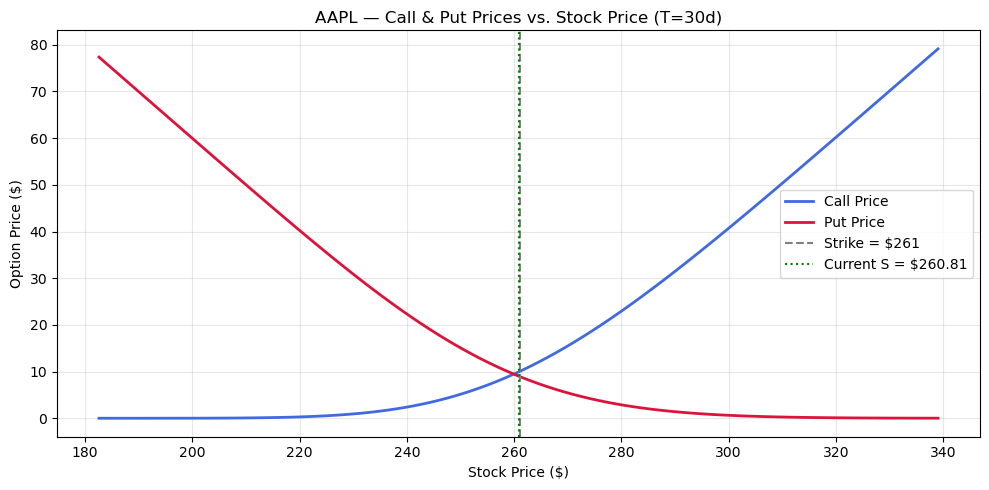

In [5]:
S_values = np.linspace(S * 0.7, S * 1.3, 100)

call_prices = [black_scholes_call(s, K, T, r, sigma) for s in S_values]
put_prices  = [black_scholes_put(s, K, T, r, sigma)  for s in S_values]

plt.figure(figsize=(10, 5))
plt.plot(S_values, call_prices, color='royalblue', lw=2, label='Call Price')
plt.plot(S_values, put_prices,  color='crimson',   lw=2, label='Put Price')
plt.axvline(K, color='gray', linestyle='--', label=f'Strike = ${K}')
plt.axvline(S, color='green', linestyle=':', label=f'Current S = ${S:.2f}')
plt.xlabel("Stock Price ($)")
plt.ylabel("Option Price ($)")
plt.title(f"{ticker} — Call & Put Prices vs. Stock Price (T=30d)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

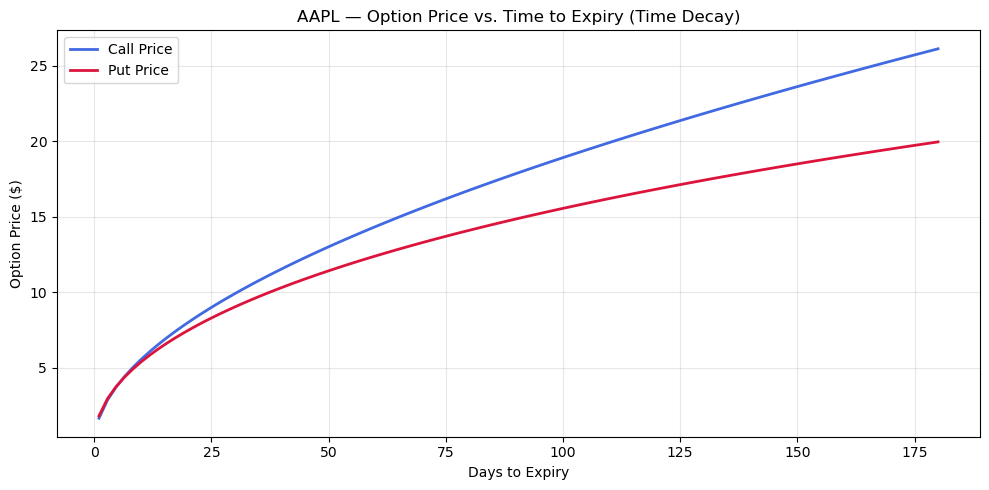

In [6]:
T_values = np.linspace(1/365, 180/365, 100)  # 1 day to 180 days

call_T = [black_scholes_call(S, K, t, r, sigma) for t in T_values]
put_T  = [black_scholes_put(S, K, t, r, sigma)  for t in T_values]

plt.figure(figsize=(10, 5))
plt.plot(T_values * 365, call_T, color='royalblue', lw=2, label='Call Price')
plt.plot(T_values * 365, put_T,  color='crimson',   lw=2, label='Put Price')
plt.xlabel("Days to Expiry")
plt.ylabel("Option Price ($)")
plt.title(f"{ticker} — Option Price vs. Time to Expiry (Time Decay)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()